# 项目 9：高级视觉 - CIFAR-100 上的迁移学习

**项目目标：** 使用预训练 CNN 架构完成 CIFAR-100 图像分类。我们会比较 ResNet50、VGG16 和 MobileNetV2，把它们在 ImageNet 上学到的视觉特征迁移到一个 100 类图像分类任务中。

### 本项目将覆盖的核心概念

1. **迁移学习：** 复用大规模数据集 ImageNet 上学到的视觉特征。
2. **预训练 CNN 主干网络：** 理解 ResNet50、VGG16、MobileNetV2 如何作为特征提取器。
3. **模型专属预处理：** 不同架构需要不同的输入预处理方式。
4. **自定义分类头：** 替换原 ImageNet 分类器，改成 CIFAR-100 的 100 类输出。
5. **冻结与微调：** 冻结大部分预训练层，只训练顶部若干层和新分类头。
6. **模型评估：** 比较准确率和训练曲线。
7. **扩展作业：** 把同样流程迁移到 Oxford Flowers 102 数据集。

CIFAR-100 包含 60,000 张彩色图片，共 100 个类别。它比 Fashion-MNIST 更复杂，因此很适合学习迁移学习。

## 1. 数据加载与预处理

我们加载 CIFAR-100，并为每个预训练主干网络准备单独的预处理版本。这样做很重要，因为不同预训练模型对输入像素的缩放和归一化要求不同。

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar100

from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet50
from tensorflow.keras.applications.vgg16 import preprocess_input as preprocess_vgg16
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mobilenetv2


(X_train, y_train), (X_test, y_test) = cifar100.load_data()

X_train_resnet50 = preprocess_resnet50(X_train)
X_test_resnet50  = preprocess_resnet50(X_test)

X_train_vgg16 = preprocess_vgg16(X_train)
X_test_vgg16  = preprocess_vgg16(X_test)

X_train_mobilenetv2 = preprocess_mobilenetv2(X_train)
X_test_mobilenetv2  = preprocess_mobilenetv2(X_test)

## 2. 模型准备

我们加载每个预训练模型时设置 `include_top=False`，表示不要使用原本为 ImageNet 设计的分类头。然后添加新的分类头，用于输出 CIFAR-100 的 100 个类别概率。

通用结构是：

```text
预训练卷积主干
-> GlobalAveragePooling2D
-> Dense 隐藏层
-> Dense(100, softmax)
```

### 2.1 使用 ResNet50

ResNet50 使用残差连接，可以帮助更深的网络稳定训练。这里我们把它作为特征提取器，并在顶部接上新的 100 类分类器。

In [2]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

# Load pre-trained ResNet50 model without the top layer
base_model_resnet50 = ResNet50(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

x = GlobalAveragePooling2D()(base_model_resnet50.output)
x = Dense(1024, activation='relu')(x)
predictions = Dense(100, activation='softmax')(x) # output layer

model_resnet50 = Model(inputs=base_model_resnet50.input, outputs=predictions)

model_resnet50.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

### 2.2 使用 VGG16

VGG16 是经典 CNN 架构，由多层卷积堆叠而成。它比 MobileNetV2 更重，也没有残差连接，但结构直观，是理解早期深度视觉模型的重要架构。

In [3]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

# Load pre-trained VGG16 model without the top layer
base_model_vgg16 = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
# Add new layers
x = GlobalAveragePooling2D()(base_model_vgg16.output)
x = Dense(512, activation='relu')(x)
predictions = Dense(100, activation='softmax')(x)
model_vgg16 = Model(inputs=base_model_vgg16.input, outputs=predictions)

model_vgg16.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 895s 15us/step


### 2.3 使用 MobileNetV2

MobileNetV2 是轻量高效的 CNN 架构。它使用深度可分离卷积和 inverted residual block，适合关注速度、模型大小和部署成本的场景。

In [4]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

# Load pre-trained MobileNetV2 model without the top layer
base_model_mobilenetv2 = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
# Add new layers
x = GlobalAveragePooling2D()(base_model_mobilenetv2.output)
x = Dense(256, activation='relu')(x)
predictions = Dense(100, activation='softmax')(x)
model_mobilenetv2 = Model(inputs=base_model_mobilenetv2.input, outputs=predictions)

model_mobilenetv2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

C:\Users\ASUS\AppData\Local\Temp\ipykernel_37396\3794676327.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model_mobilenetv2 = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 137s 15us/step


## 3. 微调与训练

微调是指让预训练模型的一部分层继续在新数据集上训练。本 notebook 中，大多数底层特征层被冻结，只开放顶部若干层进行训练。

为什么冻结底层？

- CNN 的底层通常学习边缘、纹理等通用视觉特征；
- 顶层更偏向具体任务；
- 冻结底层可以减少训练成本，也降低过拟合风险。

本项目只训练少量 epoch，用于演示完整流程。

In [ ]:
epochs = 3

print(len(model_resnet50.layers))
print(len(model_vgg16.layers))
print(len(model_mobilenetv2.layers))


# Fine-tuning ResNet50
for layer in model_resnet50.layers[:-30]:
    layer.trainable = False

for layer in model_resnet50.layers[-30:]:
    layer.trainable = True

history_resnet50 = model_resnet50.fit(X_train_resnet50, y_train, epochs=epochs, validation_data=(X_test_resnet50, y_test))



# Fine-tuning VGG16
for layer in model_vgg16.layers[:-5]:
    layer.trainable = False

for layer in model_vgg16.layers[-5:]:
    layer.trainable = True

history_vgg16 = model_vgg16.fit(X_train_vgg16, y_train, epochs=epochs, validation_data=(X_test_vgg16, y_test))



# Fine-tuning MobileNetV2
for layer in model_mobilenetv2.layers[:-40]:
    layer.trainable = False

for layer in model_mobilenetv2.layers[-40:]:
    layer.trainable = True

history_mobilenetv2 = model_mobilenetv2.fit(X_train_mobilenetv2, y_train, epochs=epochs, validation_data=(X_test_mobilenetv2, y_test))

178
22
157
Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 176s 109ms/step - accuracy: 0.3345 - loss: 2.6644 - val_accuracy: 0.3853 - val_loss: 2.4344
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 157s 101ms/step - accuracy: 0.4619 - loss: 2.0062 - val_accuracy: 0.4345 - val_loss: 2.2866
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 149s 96ms/step - accuracy: 0.5493 - loss: 1.6125 - val_accuracy: 0.4386 - val_loss: 2.5407
Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 86s 55ms/step - accuracy: 0.0685 - loss: 4.6744 - val_accuracy: 0.0552 - val_loss: 4.0465
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 89s 57ms/step - accuracy: 0.0976 - loss: 3.6803 - val_accuracy: 0.1306 - val_loss: 3.4148
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.1445 - loss: 3.3597 - val_accuracy: 0.1708 - val_loss: 3.2388
Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 50s 29ms/step - accuracy: 0.1855 - loss: 3.4290 - val_accuracy: 0.0977 - val_loss: 4.4560
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 30ms/step - accuracy: 

## 4. 模型评估

我们在 CIFAR-100 测试集上评估三个模型，并比较准确率。随后用训练曲线观察训练集和验证集的 accuracy/loss 变化，判断模型学习状态和泛化能力。

In [ ]:
acc_resnet50    = model_resnet50.evaluate(X_test_resnet50, y_test)[1]
acc_vgg16       = model_vgg16.evaluate(X_test_vgg16, y_test)[1]
acc_mobilenetv2 = model_mobilenetv2.evaluate(X_test_mobilenetv2, y_test)[1]

print(f'ResNet50 Accuracy: {acc_resnet50:.2f}')
print(f'VGG16 Accuracy: {acc_vgg16:.2f}')
print(f'MobileNetV2 Accuracy: {acc_mobilenetv2:.2f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.4386 - loss: 2.5407
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.1708 - loss: 3.2388
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.2264 - loss: 3.4489
ResNet50 Accuracy: 0.44
VGG16 Accuracy: 0.17
MobileNetV2 Accuracy: 0.23


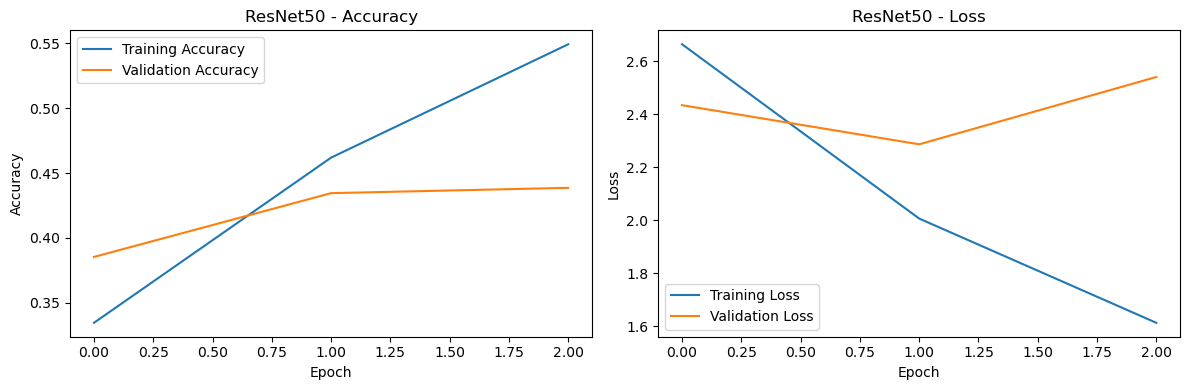

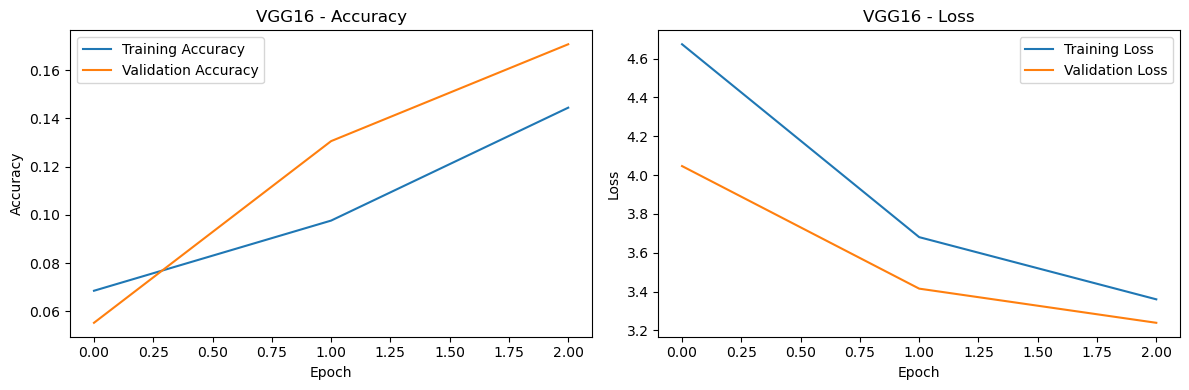

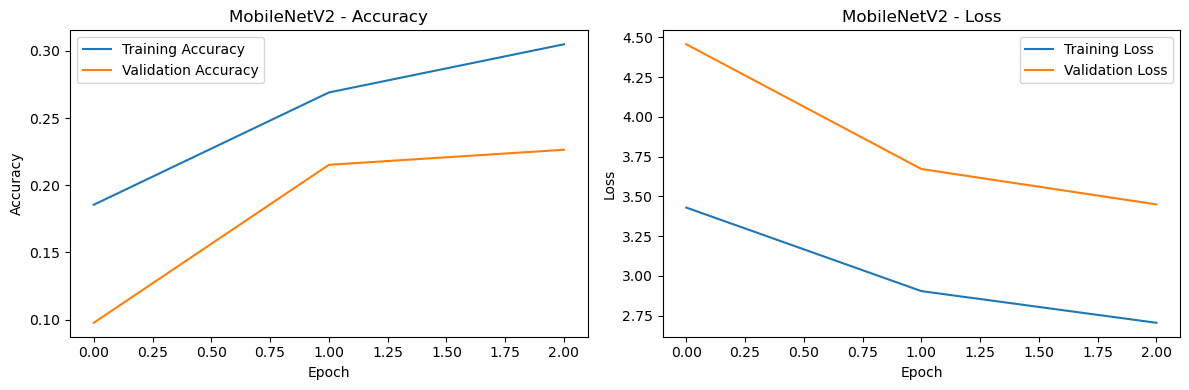

In [7]:
import matplotlib.pyplot as plt

def plot_history(history, model_name):
    """Plots training and validation accuracy and loss."""
    plt.figure(figsize=(12, 4))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Plot history for each model
plot_history(history_resnet50, 'ResNet50')
plot_history(history_vgg16, 'VGG16')
plot_history(history_mobilenetv2, 'MobileNetV2')

In [8]:
# Save the models
model_resnet50.save('resnet50_cifar100.h5')
model_vgg16.save('vgg16_cifar100.h5')
model_mobilenetv2.save('mobilenetv2_cifar100.h5')

## 项目总结

本项目展示了高级图像分类中的迁移学习流程：

1. 加载 CIFAR-100，并按不同模型要求进行预处理；
2. 加载带 ImageNet 权重但不含原分类头的 ResNet50、VGG16 和 MobileNetV2；
3. 为 CIFAR-100 添加新的 100 类分类头；
4. 解冻顶部若干层进行微调；
5. 使用准确率和训练曲线比较模型表现。

核心结论是：预训练模型能提供强大的视觉特征，但不同架构在准确率、速度、内存占用和微调难度上各有取舍。

## 项目作业：Oxford Flowers 102 上的迁移学习

请把本项目的迁移学习流程应用到 Oxford Flowers 102 数据集。

任务要求：

1. 使用 TensorFlow Datasets 加载 Oxford Flowers 102；
2. 查看 train、validation、test 三个划分；
3. 将图片 resize 到预训练模型需要的输入尺寸；
4. 应用对应模型的 preprocess 函数；
5. 使用 ResNet50、VGG16、MobileNetV2 构建迁移学习模型；
6. 解冻部分层进行微调；
7. 用 accuracy、loss 曲线和样本预测比较模型表现。

这个作业用于检验你是否能把 CIFAR-100 的迁移学习流程迁移到新的图像数据集。

In [ ]:
import tensorflow_datasets as tfds

# Load the Oxford Flowers 102 dataset
try:
    dataset, info = tfds.load('oxford_flowers102:2.1.1', with_info=True, as_supervised=True)

    # Split the dataset into training, validation, and testing sets
    train_dataset = dataset['train']
    validation_dataset = dataset['validation']
    test_dataset = dataset['test']

    # Print information about the dataset
    print(info)

except Exception as e:
    print(f"Error loading dataset: {e}")